In [1]:
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import matplotlib.colors as colors
import os
import pandas as pd
import cmocean


In [2]:
os.chdir('.../')

dxdy = xr.open_dataset('ANHA4_mesh_zgr.nc')
dx = dxdy.variables['e1t']
dy = dxdy.variables['e2t']
e3t = dxdy.variables['e3t_0']
lon = dxdy.variables['nav_lon']
lat = dxdy.variables['nav_lat']

e3t = e3t[0]

In [3]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [4]:
os.chdir('.../icb_occurence/vs')

for i in range(1, 5):
    globals()[f'x_{i}_vs'] = xr.open_dataset(f'xi_{i:02d}.nc')['xi'].values
    globals()[f'y_{i}_vs'] = xr.open_dataset(f'yj_{i:02d}.nc')['yj'].values

In [5]:
os.chdir('.../icb_occurence/vd')

for i in range(1, 5):
    globals()[f'x_{i}_vd'] = xr.open_dataset(f'xi_{i:02d}.nc')['xi'].values
    globals()[f'y_{i}_vd'] = xr.open_dataset(f'yj_{i:02d}.nc')['yj'].values

In [6]:
for i in range(1, 5):
    globals()[f'count_{i}_vs'] = np.zeros((800, 544))
    globals()[f'count_{i}_vd'] = np.zeros((800, 544))

In [7]:
for i in range(0, len(x_1_vs)):
    for j in range(0, len(x_1_vs[0])):
        if x_1_vs[i][j] > 0:
                count_1_vs[int(y_1_vs[i][j])][int(x_1_vs[i][j])] += 1
print('done')

for i in range(0, len(x_2_vs)):
    for j in range(0, len(x_2_vs[0])):
        if x_2_vs[i][j] > 0:
                count_2_vs[int(y_2_vs[i][j])][int(x_2_vs[i][j])] += 1

for i in range(0, len(x_3_vs)):
    for j in range(0, len(x_3_vs[0])):
        if x_3_vs[i][j] > 0:
                count_3_vs[int(y_3_vs[i][j])][int(x_3_vs[i][j])] += 1

for i in range(0, len(x_4_vs)):
    for j in range(0, len(x_4_vs[0])):
        if x_4_vs[i][j] > 0:
                count_4_vs[int(y_4_vs[i][j])][int(x_4_vs[i][j])] += 1


done


In [8]:
for i in range(0, len(x_1_vd)):
    for j in range(0, len(x_1_vd[0])):
        if x_1_vd[i][j] > 0:
            count_1_vd[int(y_1_vd[i][j])][int(x_1_vd[i][j])] += 1

for i in range(0, len(x_2_vd)):
    for j in range(0, len(x_2_vd[0])):
        if x_2_vd[i][j] > 0:
            count_2_vd[int(y_2_vd[i][j])][int(x_2_vd[i][j])] += 1

for i in range(0, len(x_3_vd)):
    for j in range(0, len(x_3_vd[0])):
        if x_3_vd[i][j] > 0:
            count_3_vd[int(y_3_vd[i][j])][int(x_3_vd[i][j])] += 1

for i in range(0, len(x_4_vd)):
    for j in range(0, len(x_4_vd[0])):
        if x_4_vd[i][j] > 0:
            count_4_vd[int(y_4_vd[i][j])][int(x_4_vd[i][j])] += 1


In [9]:
count_vs = count_1_vs + count_2_vs + count_3_vs + count_4_vs

count_vd = count_1_vd + count_2_vd + count_3_vd + count_4_vd

In [31]:
number = 1000

new_vs = np.copy(count_vs)
new_vs = new_vs.astype(float)
new_vs[new_vs > number] = number
new_vs[new_vs == 0] = np.nan

new_vd = np.copy(count_vd)
new_vd = new_vd.astype(float)
new_vd[new_vd > number] = number
new_vd[new_vd == 0] = np.nan

Locator attempting to generate 1000 ticks ([1.0, ..., 1000.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1000 ticks ([1.0, ..., 1000.0]), which exceeds Locator.MAXTICKS (1000).


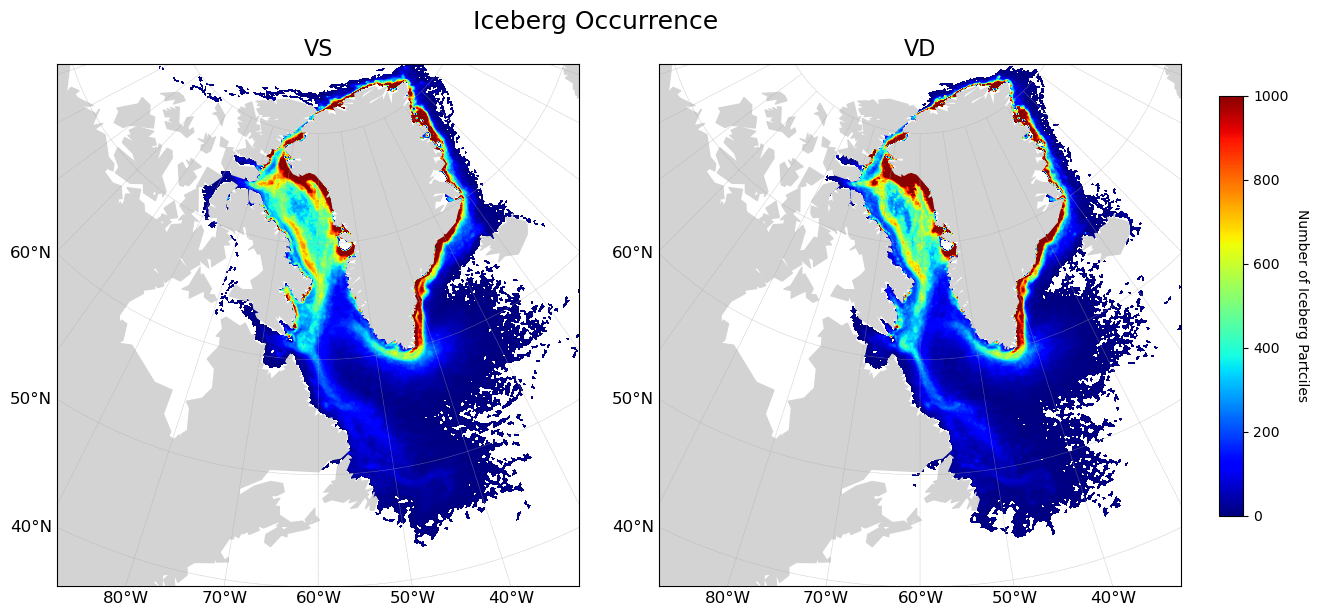

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6), constrained_layout=True)

vmin = 0
vmax = 1000
levels = 1000
new_cmap = truncate_colormap(plt.cm.jet, 0., 0.99)


data_list = [new_vs,
             new_vd]
titles = ['VS',  'VD']

for ax, data, title in zip(axes.flat, data_list, titles):
    ax.set_title(title, fontsize=16)
    m = Basemap(projection='aea', resolution='c', width=5E6, height=5E6, lat_0=63, lon_0=-60, ax=ax)
    m.contourf(lon, lat, data, latlon=True, levels=levels, vmin=vmin, vmax=vmax, cmap=new_cmap)
    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0,360,10), labels=[0, 0, 0, 1], linewidth=0.4, color='darkgray', fontsize=12)
    m.drawparallels(np.arange(-90,90,10), labels=[1, 0, 0, 0], linewidth=0.4, color='darkgray', fontsize=12)

cax = fig.add_axes([1.02, 0.15, 0.02, 0.7])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb1 = mpl.colorbar.ColorbarBase(cax, cmap=new_cmap, norm=norm, orientation='vertical')
cb1.ax.set_ylabel('Number of Iceberg Partciles', rotation=270, labelpad=15)
cb1.ax.ticklabel_format(style='sci', scilimits=(-1,4), axis='both')

fig.suptitle('Iceberg Occurrence', fontsize=18)

plt.show()


In [32]:
output_path = '.../Figure2&12_ConvectiverResistance/icb_occurence'

save_path = (f"{output_path}/icb_count_vs.npz")
np.savez(save_path, icb_count=new_vs)

save_path = (f"{output_path}/icb_count_vd.npz")
np.savez(save_path, icb_count=new_vd)

In [33]:
os.chdir('.../Figure2&12_ConvectiverResistance/icb_occurence')

vs = np.load('icb_count_vs.npz')
vs = vs['icb_count']

vd = np.load('icb_count_vd.npz')
vd = vd['icb_count']

dif = vd - vs


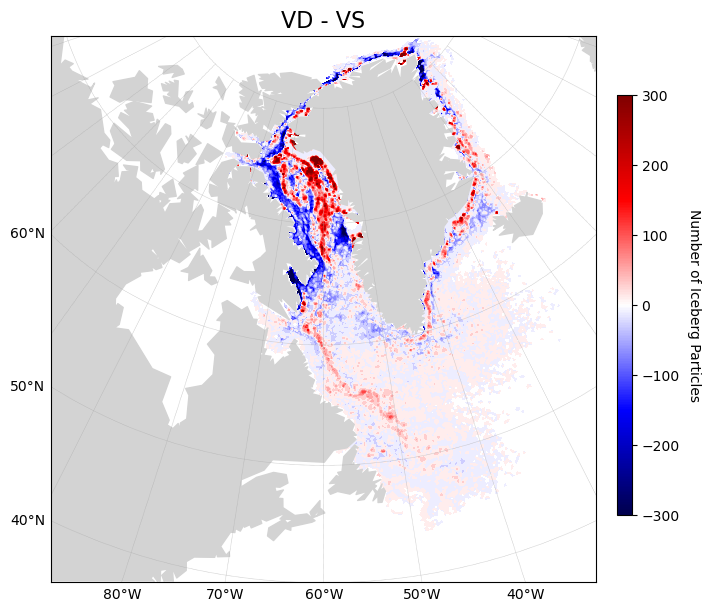

In [35]:
vmin = -300
vmax = 300
n_levels = 100
levels = 100
cmap = plt.get_cmap('seismic') 

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 6), constrained_layout=True)

data_list = [dif]
titles = ['VD - VS']

for ax, data, title in zip([axes], data_list, titles):
    ax.set_title(title, fontsize=16)

    m = Basemap(projection='aea', resolution='c', width=5E6, height=5E6,
                lat_0=63, lon_0=-60, ax=ax)

    m.contourf(lon, lat, data, latlon=True, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap)
    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0, 360, 10), labels=[0, 0, 0, 1], linewidth=0.4, color='darkgray', fontsize=10)
    m.drawparallels(np.arange(-90, 90, 10), labels=[1, 0, 0, 0], linewidth=0.4, color='darkgray', fontsize=10)

cax = fig.add_axes([1.02, 0.15, 0.025, 0.7])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb1 = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
cb1.ax.set_ylabel('Number of Iceberg Particles', rotation=270, labelpad=15)
cb1.ax.ticklabel_format(style='sci', scilimits=(-1, 4), axis='both')

plt.show()
